<a href="https://colab.research.google.com/github/abeerhani-cloud/AAI614/blob/main/IQR_Outlier_Detection_Iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IQR Outlier Detection in Python

This notebook implements the **Interquartile Range (IQR)** algorithm to detect outliers.

We use the built-in **Iris dataset** from `scikit-learn`. The Iris dataset contains flower measurements such as sepal length, sepal width, petal length, and petal width.


In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Display first rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Basic dataset information
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Implementing the IQR Algorithm

In [3]:
def detect_outliers_iqr(dataframe, column):
    # Detect outliers in a numerical column using the IQR method.
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

    return lower_bound, upper_bound, outliers

# Test the function on one column
lower, upper, outliers = detect_outliers_iqr(df, 'sepal width (cm)')

print('Lower bound:', lower)
print('Upper bound:', upper)
print('Number of outliers:', len(outliers))
outliers

Lower bound: 2.05
Upper bound: 4.05
Number of outliers: 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


## Detecting outliers in all numerical columns

In [4]:
numeric_columns = df.select_dtypes(include=np.number).columns

results = []

for col in numeric_columns:
    lower, upper, outlier_rows = detect_outliers_iqr(df, col)
    results.append({
        'Column': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Number of Outliers': len(outlier_rows)
    })

results_df = pd.DataFrame(results)
results_df

,Column,Lower Bound,Upper Bound,Number of Outliers
0,sepal length (cm),3.15,8.35,0
1,sepal width (cm),2.05,4.05,4
2,petal length (cm),-3.65,10.35,0
3,petal width (cm),-1.95,4.05,0


## Show the actual outlier rows

In [5]:
for col in numeric_columns:
    lower, upper, outlier_rows = detect_outliers_iqr(df, col)
    print(f'\nColumn: {col}')
    print(f'Lower bound: {lower:.2f}, Upper bound: {upper:.2f}')
    print(f'Number of outliers: {len(outlier_rows)}')
    display(outlier_rows)


Column: sepal length (cm)
Lower bound: 3.15, Upper bound: 8.35
Number of outliers: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species



Column: sepal width (cm)
Lower bound: 2.05, Upper bound: 4.05
Number of outliers: 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor



Column: petal length (cm)
Lower bound: -3.65, Upper bound: 10.35
Number of outliers: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species



Column: petal width (cm)
Lower bound: -1.95, Upper bound: 4.05
Number of outliers: 0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species


## Visualizing outliers with boxplots

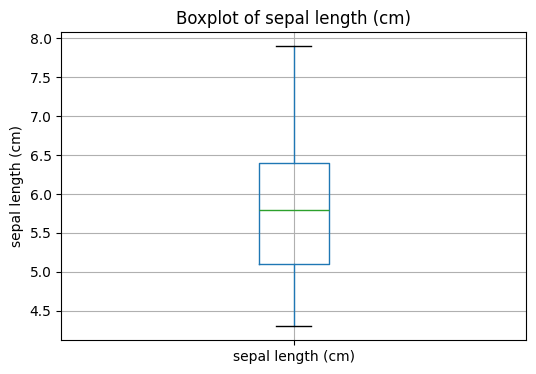

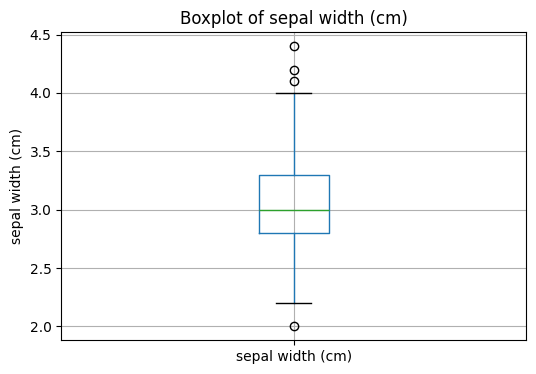

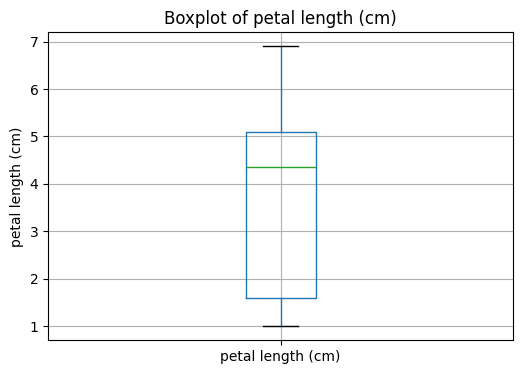

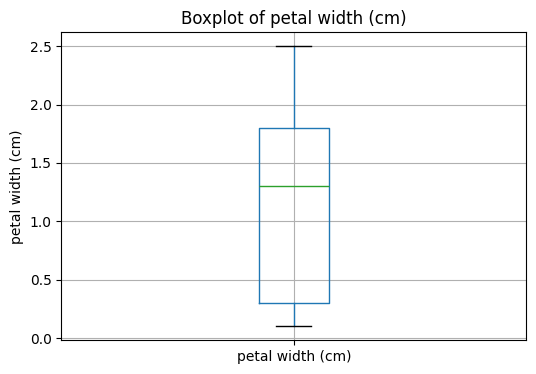

In [6]:
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()